In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

print("Libraries loaded")

Libraries loaded


In [5]:
df = pd.read_csv('../data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)

print("Model trained")

Model trained


In [6]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (56962, 30)


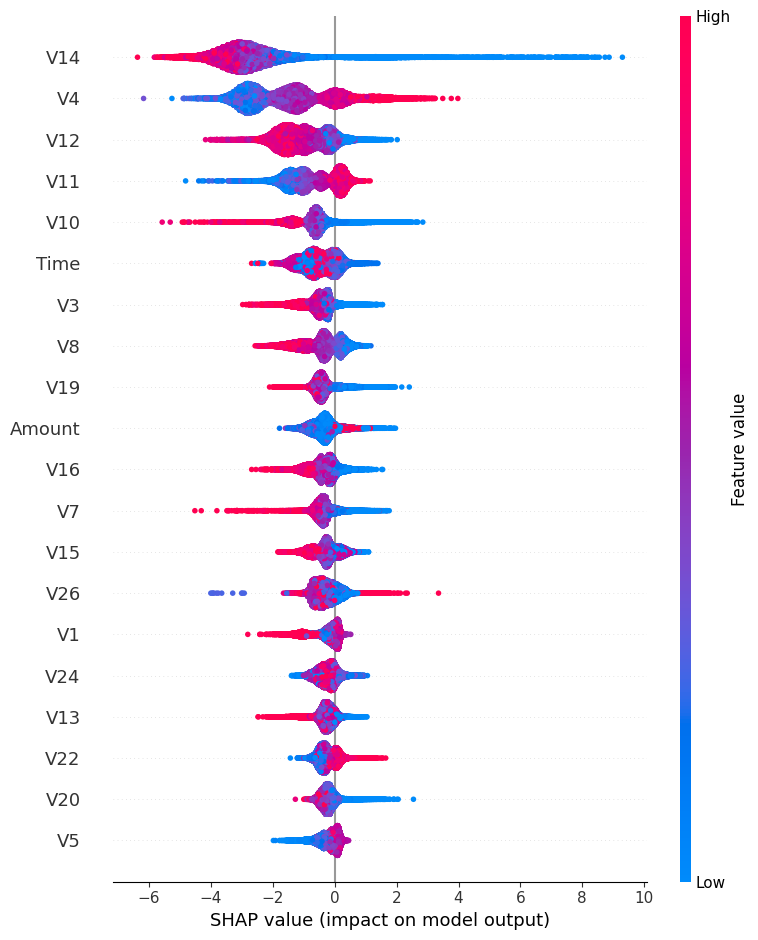

In [7]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Waterfall plot - single prediction explanation
fraud_indices = np.where(y_test == 1)[0]
sample_idx = fraud_indices[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled[sample_idx],
        feature_names=X.columns.tolist()
    )
)
plt.savefig('../outputs/figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()